In [25]:
from copy import deepcopy

from typing import Any
from typing import Self
from typing import Iterator

import queue

import numpy as np
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout

In [6]:
class Node:
    def __init__(self, pos: tuple[int, int], data: Any):
        self.pos = pos
        self.data = data
        self.neighbors: list[Node] = []

    def connect(self, other: Self) -> None:
        if other not in self.neighbors:
            self.neighbors.append(other)   
            other.neighbors.append(self) 

    def __repr__(self) -> str:
        return f"{self.pos=}{len(self.neighbors)}"

    def __str__(self) -> str:
        return repr(self)

    def __len__(self) -> None:
        return len(self.neighbors)
    
    def __eq__(self, other: Self) -> bool:
        return self.pos == other.pos

In [20]:
class Labyrinth:
    def __init__(self, height: int, width: int, alpha: float=0.6):
        self.height = height
        self.width = width
        self.nodes: dict[tuple[int, int], Node] = {}
        self.alpha = alpha

    def generate(self) -> None:

        for i in range(self.height):
            for j in range(self.width):
                node = Node(pos=(i, j), data=i * self.width + j)
                self.nodes[node.pos] = node

        for h in range(1, self.height):
            if np.random.rand() < self.alpha:
                self.nodes[(h, 0)].connect(self.nodes[(h - 1, 0)])
        for w in range(1, self.width):
            if np.random.rand() < self.alpha:
                self.nodes[(0, w)].connect(self.nodes[(0, w - 1)])
        for h in range(1, self.height):
            for w in range(1, self.width):
                if np.random.rand() < self.alpha:
                    self.nodes[(h, w)].connect(self.nodes[(h, w - 1)])
                if np.random.rand() < self.alpha:
                    self.nodes[(h, w)].connect(self.nodes[(h - 1, w)])
        
        self.root = self.nodes[(0, 0)]

    def to_nx(self) -> nx.DiGraph:
        g = nx.Graph(data=None)
        pos = {}

        for node in self.nodes.values():
            g.add_node(node.pos, data=node.data)
            pos[node.pos] = node.pos

            for neighbor in node.neighbors:
                if neighbor.pos[0] <= node.pos[0] or neighbor.pos[1] <= node.pos[1]:
                    g.add_edge(node.pos, neighbor.pos)

        return g, pos
        

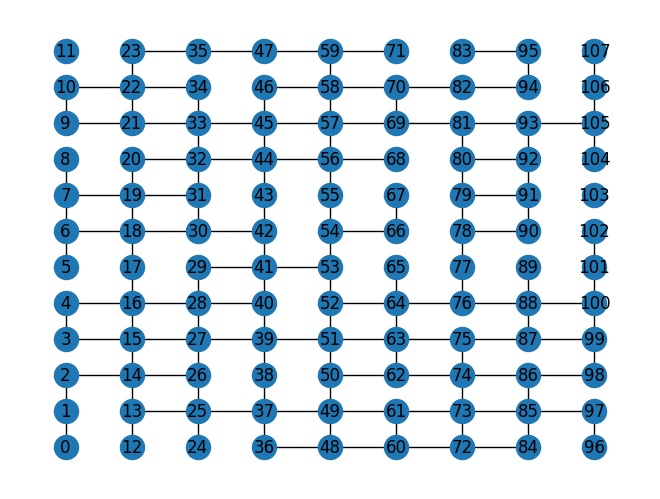

In [24]:
HEIGHT, WIDTH = 9, 12
ALPHA = 0.7

lab = Labyrinth(height=HEIGHT, width=WIDTH, alpha=ALPHA)

lab.generate()

g, pos = lab.to_nx()

nx.draw(g, labels=nx.get_node_attributes(g, "data"), pos=pos)